# **Modelos LSTM — Total mensual de viajeros**

En este notebook se trabaja la serie del **total mensual de viajeros**. La idea es probar modelos LSTM con distintas configuraciones, tunear algunos hiperparámetros y después quedarnos con la opción que tenga mejor desempeño.



## **1.1. Conjuntos de entrenamiento y prueba**

Para comparar los resultados con los modelos del Laboratorio 1, se usan los mismos archivos de entrenamiento y prueba: entrenamiento.csv y prueba.csv. 

El entrenamiento va de enero de 2009 a marzo de 2021, con 147 meses. La prueba va de abril de 2021 a junio de 2026, con 63 meses. La partición se mantiene en orden cronológico, porque en series de tiempo no conviene mezclar observaciones pasadas y futuras.

En este caso, la serie total mensual se reconstruye sumando los viajeros de cada mes y aplicando la misma transformación logarítmica usada en el laboratorio anterior. Luego, para calcular MAE y RMSE, se regresa a la escala original de viajeros usando la exponencial. Esto permite comparar los errores contra los modelos anteriores en las mismas unidades.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "lstm" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import config
import utils

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 5)

SERIE = "total"
PERIODO = config.PERIODO

serie_train = utils.construir_serie(SERIE, "train")
serie_prueba = utils.construir_serie(SERIE, "prueba")

serie_train_log = np.log(serie_train)
serie_prueba_log = np.log(serie_prueba)

print("Serie:", config.SERIES_LAB1[SERIE]["etiqueta"])
print(f"Entrenamiento: {serie_train.index.min():%Y-%m} a {serie_train.index.max():%Y-%m}  "
      f"({len(serie_train)} meses)")
print(f"Prueba       : {serie_prueba.index.min():%Y-%m} a {serie_prueba.index.max():%Y-%m}  "
      f"({len(serie_prueba)} meses)")
print("Frecuencia   :", serie_train.index.freqstr, "(mensual, inicio de mes)")
print("Meses sin registro:", int(serie_train.isna().sum() + serie_prueba.isna().sum()))
print()
print("Mejor modelo para esta serie:")
print(f"  {config.MEJORES_LAB1[SERIE]['modelo']}  "
      f"MAE={config.MEJORES_LAB1[SERIE]['MAE']:,.0f}  "
      f"RMSE={config.MEJORES_LAB1[SERIE]['RMSE']:,.0f}")

serie_train.tail()

Serie: Total mensual
Entrenamiento: 2009-01 a 2021-03  (147 meses)
Prueba       : 2021-04 a 2026-06  (63 meses)
Frecuencia   : MS (mensual, inicio de mes)
Meses sin registro: 0

Mejor modelo para esta serie:
  Suav. exp. simple  MAE=158,777  RMSE=173,709


Fecha
2020-11-01    52865.000000
2020-12-01    55620.000000
2021-01-01    89960.000000
2021-02-01    52605.000000
2021-03-01    85017.396333
Freq: MS, Name: Viajero, dtype: float64

## **1.2. Diseño del tuneo de hiperparámetros**

Primero se comparan dos tipos de modelos LSTM:

1. **LSTM simple**: tiene una sola capa LSTM. Se usa como punto de comparación porque es un modelo más sencillo y debería tener menor riesgo de sobreajuste.
2. **LSTM apilada**: tiene dos capas LSTM y usa dropout. Esta tiene más capacidad para aprender patrones más complejos, pero también puede sobreajustarse más fácil, por eso se regulariza.

Los hiperparámetros que se tunean son:

- ventana: se prueban 12 y 24 meses. Con 12 meses el modelo ve un ciclo anual completo; con 24 meses puede usar dos ciclos anuales.
- unidades: se prueban 16 y 32 unidades. No se usan redes muy grandes porque la serie mensual no tiene demasiadas observaciones.
- dropout: se prueba solo en la LSTM apilada, ya que ahí hay más riesgo de sobreajuste.
- tasa_aprendizaje: se prueban 0.001 y 0.005 para ver qué tan rápido conviene que aprenda Adam.

Se dejan fijos batch_size = 16, epochs = 250 y early stopping. El early stopping ayuda a que el entrenamiento se detenga cuando el modelo ya no mejora, en lugar de forzar todas las épocas.

Para escoger la mejor configuración se usa validación de origen rodante. Esto significa que el modelo siempre entrena con meses anteriores y valida con los meses siguientes, respetando el orden de la serie. 

In [2]:
grilla_dos_modelos = []

for ventana in (12, 24):
    for tasa_aprendizaje in (0.001, 0.005):
        for unidades in (16, 32):
            grilla_dos_modelos.append({
                "familia": "A_simple",
                "ventana": ventana,
                "unidades": unidades,
                "capas": 1,
                "dropout": 0.0,
                "tasa_aprendizaje": tasa_aprendizaje,
                "epocas": 250,
                "paciencia": 30,
                "lote": 16,
            })

        for dropout in (0.1, 0.2):
            grilla_dos_modelos.append({
                "familia": "B_apilada_dropout",
                "ventana": ventana,
                "unidades": 32,
                "capas": 2,
                "dropout": dropout,
                "tasa_aprendizaje": tasa_aprendizaje,
                "epocas": 250,
                "paciencia": 30,
                "lote": 16,
            })

tabla_grilla = pd.DataFrame(grilla_dos_modelos)
print(f"Configuraciones a evaluar: {len(tabla_grilla)}")
tabla_grilla

Configuraciones a evaluar: 16


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas,paciencia,lote
0,A_simple,12,16,1,0.0,0.001,250,30,16
1,A_simple,12,32,1,0.0,0.001,250,30,16
2,B_apilada_dropout,12,32,2,0.1,0.001,250,30,16
3,B_apilada_dropout,12,32,2,0.2,0.001,250,30,16
4,A_simple,12,16,1,0.0,0.005,250,30,16
5,A_simple,12,32,1,0.0,0.005,250,30,16
6,B_apilada_dropout,12,32,2,0.1,0.005,250,30,16
7,B_apilada_dropout,12,32,2,0.2,0.005,250,30,16
8,A_simple,24,16,1,0.0,0.001,250,30,16
9,A_simple,24,32,1,0.0,0.001,250,30,16


### **1.2.a. Tuneo con validación temporal**

La siguiente celda ejecuta el tuneo. Cada configuración se evalúa en varios cortes de 12 meses y se ordena usando el RMSE promedio de validación en la escala original de viajeros.

Se usa RMSE como métrica principal porque penaliza más los errores grandes. Esto es importante en esta serie, ya que hay meses con cambios fuertes, especialmente alrededor de la pandemia.



In [3]:
USAR_CACHE = True

tabla_tuneo = utils.tunear_con_cache(
    clave_serie=f"{SERIE}_dos_modelos",
    valores_train_log=serie_train_log.values,
    grilla=grilla_dos_modelos,
    usar_cache=USAR_CACHE,
    n_cortes=4,
    tamano_val=12,
    semilla=config.SEMILLA,
    verbose=True,
)

columnas_tuneo = [
    "familia", "ventana", "unidades", "capas", "dropout", "tasa_aprendizaje",
    "RMSE_val", "MAE_val", "RMSE_std", "RMSE_val_sin_ultimo", "n_cortes", "rmse_por_corte",
]

tabla_tuneo[columnas_tuneo].head(10)

Configuraciones     : 16


Cortes de validacion: [(99, 111), (111, 123), (123, 135), (135, 147)]


Entrenamientos      : 64


Semilla             : 123


[cargado] tuneo_lstm_total_dos_modelos.csv: 16 ya corridas, se retoman


[ok] el tuneo ya estaba completo


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,RMSE_val,MAE_val,RMSE_std,RMSE_val_sin_ultimo,n_cortes,rmse_por_corte
0,A_simple,12,16,1,0.0,0.005,111887.964047,98925.496333,96249.433380,56832.477795,4,"[65406.9, 35630.0, 69460.6, 277054.4]"
1,B_apilada_dropout,12,32,2,0.1,0.005,112560.331552,101308.123260,97425.291485,56668.436343,4,"[61087.0, 39448.9, 69469.4, 280236.0]"
2,B_apilada_dropout,12,32,2,0.2,0.005,112736.772904,102123.221806,99049.330820,56011.071801,4,"[61892.6, 36077.2, 70063.4, 282913.9]"
3,B_apilada_dropout,12,32,2,0.1,0.001,112929.003993,102266.173488,102406.670522,54294.688661,4,"[59180.7, 33728.5, 69974.9, 288831.9]"
4,B_apilada_dropout,24,32,2,0.1,0.005,113649.174570,102708.306654,99065.846155,56909.125657,4,"[63980.4, 36821.1, 69925.9, 283869.3]"
5,B_apilada_dropout,12,32,2,0.2,0.001,114652.375429,103551.264314,100651.665251,56942.839897,4,"[60189.3, 38849.4, 71789.8, 287781.0]"
6,A_simple,12,16,1,0.0,0.001,115007.716636,101383.719895,96639.857615,59468.411458,4,"[65748.7, 44443.1, 68213.4, 281625.6]"
7,B_apilada_dropout,24,32,2,0.2,0.005,115983.940076,104215.817899,97276.235836,60528.686196,4,"[75870.3, 35621.4, 70094.4, 282349.7]"
8,A_simple,12,32,1,0.0,0.001,119403.644319,105859.191842,97966.991994,63143.840450,4,"[74666.0, 47160.2, 67605.3, 288183.1]"
9,B_apilada_dropout,24,32,2,0.1,0.001,120576.163201,108429.415227,104858.813267,60805.061656,4,"[63309.0, 36089.7, 83016.5, 299889.5]"


### **1.2.b. Selección del mejor modelo por familia**

Para mostrar claramente los dos modelos pedidos, se toma el mejor resultado de cada familia: el mejor LSTM simple y el mejor LSTM apilado con dropout.

Después se escoge el mejor modelo global usando el menor RMSE_val. También se revisa la desviación del RMSE entre cortes (RMSE_std), porque si un modelo varía demasiado entre validaciones puede ser menos confiable.

In [4]:
idx_mejores = tabla_tuneo.groupby("familia")["RMSE_val"].idxmin()
mejor_por_familia = tabla_tuneo.loc[idx_mejores].sort_values("RMSE_val").reset_index(drop=True)
mejor_global = mejor_por_familia.iloc[0]

print("Mejor configuracion global segun validacion temporal:")
print(f"  Familia             : {mejor_global['familia']}")
print(f"  Ventana             : {int(mejor_global['ventana'])} meses")
print(f"  Unidades            : {int(mejor_global['unidades'])}")
print(f"  Capas LSTM          : {int(mejor_global['capas'])}")
print(f"  Dropout             : {float(mejor_global['dropout']):.2f}")
print(f"  Tasa de aprendizaje : {float(mejor_global['tasa_aprendizaje']):.4f}")
print(f"  RMSE validacion     : {mejor_global['RMSE_val']:,.0f} viajeros")
print(f"  Desv. RMSE cortes   : {mejor_global['RMSE_std']:,.0f} viajeros")

mejor_por_familia[columnas_tuneo]

Mejor configuracion global segun validacion temporal:
  Familia             : A_simple
  Ventana             : 12 meses
  Unidades            : 16
  Capas LSTM          : 1
  Dropout             : 0.00
  Tasa de aprendizaje : 0.0050
  RMSE validacion     : 111,888 viajeros
  Desv. RMSE cortes   : 96,249 viajeros


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,RMSE_val,MAE_val,RMSE_std,RMSE_val_sin_ultimo,n_cortes,rmse_por_corte
0,A_simple,12,16,1,0.0,0.005,111887.964047,98925.496333,96249.433380,56832.477795,4,"[65406.9, 35630.0, 69460.6, 277054.4]"
1,B_apilada_dropout,12,32,2,0.1,0.005,112560.331552,101308.123260,97425.291485,56668.436343,4,"[61087.0, 39448.9, 69469.4, 280236.0]"


### **1.2.c. Entrenamiento final de los modelos seleccionados**

Después del tuneo, los hiperparámetros ya quedan definidos. Con esas configuraciones se vuelven a entrenar los modelos.

Se calculan dos tipos de predicción:

- **Pronóstico recursivo**: predice todo el periodo de prueba desde el final del entrenamiento y va usando sus propias predicciones para seguir avanzando. Este es el que se debe comparar contra los modelos del Laboratorio 1.
- **Pronóstico a un paso**: predice cada mes usando los valores reales de los meses anteriores. Sirve como diagnóstico, pero no es la comparación principal porque usa información real dentro del periodo de prueba.

In [5]:
# Entrenamiento final de la mejor configuracion de cada familia sobre todo el
# entrenamiento, y evaluacion contra prueba en los dos modos de pronostico.
# La mecanica vive en utils.entrenar_evaluar_final porque es identica para
# cualquier serie; aqui solo se decide QUE configuraciones se entrenan.
modelos_finales, filas_resumen = {}, []

for _, fila in mejor_por_familia.iterrows():
    cfg = utils.cfg_desde_fila(fila)
    resultado = utils.entrenar_evaluar_final(cfg, serie_train_log, serie_prueba_log)
    modelos_finales[cfg["familia"]] = resultado
    filas_resumen.append(resultado["resumen"])

tabla_modelos_finales = (pd.DataFrame(filas_resumen)
                         .sort_values("RMSE_recursivo").reset_index(drop=True))
tabla_modelos_finales


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas_entrenadas,MAE_recursivo,RMSE_recursivo,MAPE_recursivo_%,MAE_un_paso,RMSE_un_paso,MAPE_un_paso_%
0,B_apilada_dropout,12,32,2,0.1,0.005,250,80354.113126,92383.439396,32.769701,42717.800402,52632.900739,18.794479
1,A_simple,12,16,1,0.0,0.005,250,130873.392328,147388.488130,50.356549,43474.566887,53372.590632,18.380017


### **1.2.d. Interpretación de la selección**

La selección se justifica en dos etapas. Primero con la validación temporal, que es donde se eligen
los hiperparámetros: ahí no se toca el conjunto de prueba, de tal forma que la decisión se toma sin
ver el futuro. Después se revisa el desempeño sobre prueba, y para eso se usan el MAE y el RMSE del
pronóstico recursivo, ya que ese es el escenario que realmente interesa, el de predecir varios meses
hacia adelante sin volver a ver un dato real, y además es el único comparable contra el Laboratorio 1.

En esta serie ganó la **LSTM apilada con dropout**, es decir la de dos capas con 32 unidades y
dropout de 0.1, por encima de la simple: 92,383 contra 147,388 de RMSE recursivo, y 32.8% contra
50.4% de MAPE. Cabe mencionar un matiz importante, y es que en el pronóstico a un paso las dos
quedan prácticamente empatadas, con 52,633 y 53,373 de RMSE, de tal forma que la ventaja de la
apilada no está en aprender mejor el patrón mes a mes sino en aguantar mejor la extrapolación a 63
meses, que es donde la simple se desvía.

Que aquí gane la arquitectura con más capacidad, al contrario de lo que ocurrió en las series
individuales, tiene una explicación razonable. Al ser la serie agregada, que suma todas las regiones,
vías y fronteras, el ruido de cada punto de ingreso se compensa al sumarlos, de tal forma que la
señal es más limpia y hay de dónde aprender sin quedarse memorizando ruido. En una serie individual,
en cambio, esa misma capacidad extra se termina usando para ajustarse a fluctuaciones que no se
repiten.

Bajo esta idea, considero que el contraste entre las dos series es en sí mismo un resultado: no hay
una arquitectura que sea mejor siempre, y la elección depende de cuánta señal tenga la serie frente
a su ruido, que es justamente lo que el tuneo por validación temporal permite descubrir en lugar de
suponer.


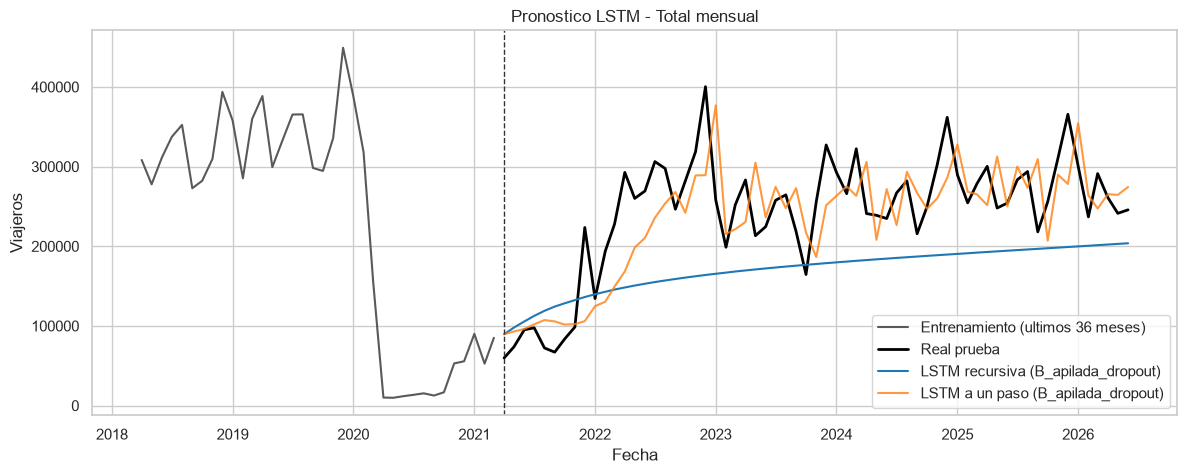

In [6]:
mejor_familia_prueba = tabla_modelos_finales.iloc[0]["familia"]
pred_mejor = modelos_finales[mejor_familia_prueba]["predicciones"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_train.tail(36).index, serie_train.tail(36).values, label="Entrenamiento (ultimos 36 meses)", color="0.35")
ax.plot(serie_prueba.index, serie_prueba.values, label="Real prueba", color="black", linewidth=2)
ax.plot(pred_mejor.index, pred_mejor["pred_recursiva"], label=f"LSTM recursiva ({mejor_familia_prueba})", color="#1f77b4")
ax.plot(pred_mejor.index, pred_mejor["pred_un_paso"], label=f"LSTM a un paso ({mejor_familia_prueba})", color="#ff7f0e", alpha=0.8)

ax.axvline(serie_prueba.index.min(), color="0.2", linestyle="--", linewidth=1)
ax.set_title(f"Pronostico LSTM - {config.SERIES_LAB1[SERIE]['etiqueta']}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Viajeros")
ax.legend()
plt.show()

### **1.2.e. Comparación de los dos modelos contra el conjunto de prueba**


In [7]:
# Comparacion de ambos modelos sobre el conjunto de PRUEBA, en los dos modos.
comparacion_modelos = tabla_modelos_finales[[
    "familia", "ventana", "unidades", "tasa_aprendizaje",
    "RMSE_recursivo", "MAPE_recursivo_%", "RMSE_un_paso", "MAPE_un_paso_%",
]].copy()

display(comparacion_modelos.style.format({
    "tasa_aprendizaje": "{:.4f}",
    "RMSE_recursivo": "{:,.0f}", "MAPE_recursivo_%": "{:.1f}",
    "RMSE_un_paso": "{:,.0f}", "MAPE_un_paso_%": "{:.1f}",
}).hide(axis="index"))


familia,ventana,unidades,tasa_aprendizaje,RMSE_recursivo,MAPE_recursivo_%,RMSE_un_paso,MAPE_un_paso_%
B_apilada_dropout,12,32,0.0050,"92,383",32.8,"52,633",18.8
A_simple,12,16,0.0050,"147,388",50.4,"53,373",18.4


In [8]:
# Mejor modelo por RMSE recursivo y sus diferencias contra el segundo.
mejor = utils.reporte_mejor_vs_segundo(tabla_modelos_finales)


MEJOR MODELO LSTM: familia B_apilada_dropout
Configuracion  : ventana=12, unidades=32, capas=2, dropout=0.1, lr=0.0050
Epocas         : 250
Recursivo      : RMSE 92,383  MAE 80,354  MAPE 32.8%
A un paso      : RMSE 52,633  MAE 42,718  MAPE 18.8%

Frente al segundo (familia A_simple, lr=0.0050):
  RMSE : 92,383 vs 147,388  -> 55,005 menos (37.3% mejor)
  MAPE : 32.8% vs 50.4%  -> 17.6 puntos porcentuales menos

Recursivo contra un paso (veces que crece el error al extrapolar):
  B_apilada_dropout      1.8x
  A_simple               2.8x


## **1.3. Predicción con el mejor modelo**

Con el mejor modelo se predice el conjunto de prueba completo, de abril de 2021 a junio de 2026, y
adicional se extiende el pronóstico hasta diciembre de 2027, siguiendo el mismo criterio que se usó
en el Laboratorio 1 para poder comparar las proyecciones de forma equivalente.

Cabe mencionar que la extensión más allá de junio de 2026 es un pronóstico puro, ya que ahí no hay
dato real contra el cual medir, mientras que el tramo de prueba sí se puede evaluar. Bajo esta idea,
también se muestra el total anual real contra el predicho, ya que el gráfico mensual permite ver la
forma de la predicción pero el acumulado anual es el que deja claro si el modelo capturó o no el
nivel al que realmente se recuperó el turismo.

Adicional, conviene tener presente que en esta serie el mejor modelo resultó ser el más complejo de los probados, es decir la LSTM apilada de dos capas con dropout, al contrario de lo que ocurrió en las series individuales. Considero que eso tiene sentido, ya que al haber más señal y menos ruido en una serie agregada, un modelo con más capacidad tiene de dónde aprender sin quedarse memorizando el ruido.


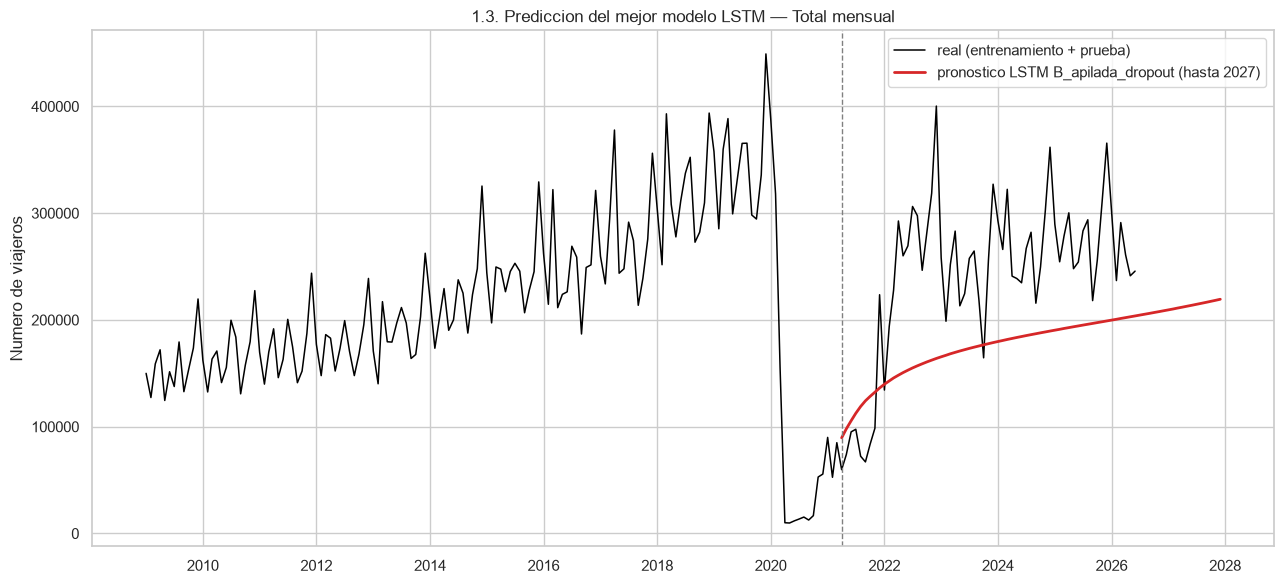

,real,predicho_LSTM
2022,"3,229,329","1,837,770"
2023,"2,917,827","2,069,705"
2024,"3,274,436","2,217,562"
2025,"3,352,289","2,336,829"
2026,"1,576,619","2,449,645"
2027,nan,"2,570,913"


In [9]:
# Pronostico del mejor modelo, extendido hasta diciembre de 2027.
familia_mejor = mejor["familia"]
ajuste_mejor = modelos_finales[familia_mejor]
pred_mejor = ajuste_mejor["predicciones"]
pred_futuro = utils.pronostico_extendido(ajuste_mejor, int(mejor["ventana"]))

serie_real_completa = pd.concat([serie_train, serie_prueba])

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie_real_completa.index, serie_real_completa.values,
        color="black", linewidth=1.1, label="real (entrenamiento + prueba)")
ax.plot(pred_futuro.index, pred_futuro.values, color="tab:red", linewidth=2,
        label=f"pronostico LSTM {familia_mejor} (hasta 2027)")
ax.axvline(serie_prueba.index[0], color="gray", linestyle="--", linewidth=1)
ax.set_title(f"1.3. Prediccion del mejor modelo LSTM — {config.SERIES_LAB1[SERIE]['etiqueta']}")
ax.set_ylabel("Numero de viajeros")
ax.legend()
plt.tight_layout()
plt.show()

# Total anual real contra predicho, mismo criterio de acumulado del Lab 1.
totales_anuales = pd.DataFrame({
    "real": serie_real_completa.groupby(serie_real_completa.index.year).sum(),
    "predicho_LSTM": pred_futuro.groupby(pred_futuro.index.year).sum(),
}).loc[[2022, 2023, 2024, 2025, 2026, 2027]]
display(totales_anuales.style.format("{:,.0f}"))


## **1.4. Comparación contra el mejor modelo del Laboratorio 1**

Finalmente se compara el mejor modelo LSTM contra el mejor modelo que se obtuvo para esta serie en
el laboratorio anterior. Los criterios que se siguieron para que la comparación sea válida son
tres. Primero, se usaron **los mismos conjuntos de entrenamiento y prueba**, sin volver a decidir
nada sobre los datos. Segundo, se evaluó **la misma tarea**: un pronóstico de 63 meses desde el
final del entrenamiento, sin que el modelo vuelva a ver ningún dato real del período de prueba, que
es exactamente lo que hicieron los modelos del Laboratorio 1 con su `forecast`. Y tercero, los
errores se calcularon **en la escala original de viajeros**, deshaciendo el logaritmo, de tal forma
que ambos modelos se miden en las mismas unidades.

Adicional, cabe mencionar que el MAPE del modelo del Laboratorio 1 no se reportó en aquel
laboratorio, por lo que se reajusta ese modelo sobre el mismo entrenamiento para poder calcularlo y
que la tabla no quede con huecos. Ese reajuste se valida verificando que reproduzca exactamente el
MAE y el RMSE que se reportaron antes, de tal forma que no se esté comparando contra un modelo
distinto al original.

---

### **Discusión**

En este caso el mejor modelo LSTM presenta una diferencia bastante considerable entre el mejor
modelo del Laboratorio 1 y el presente.

En el Laboratorio 1, el modelo que mejores métricas presentó fue el suavizamiento exponencial
simple, ganándole al resto de modelos e incluso a las series de tiempo SARIMA que se realizaron, ya
que la mayoría de los otros modelos aprendían la tendencia. Y el hecho de que se tuviera una
pandemia de por medio, en donde se pasó de un pico en 2019 a prácticamente cero, hacía que
aprendieran eso como parte del patrón y que por ende ya no lograran interpretar que después de la
pandemia poco a poco el turismo iba a volver a crecer.

Sin embargo, en los LSTM, viendo la gráfica, se identifica que en vez de quedarse de forma
constante, que es lo que se miraba en los gráficos del Laboratorio 1, donde veíamos que comenzaba a
subir un poco el turismo y ya después nuestra proyección era prácticamente una constante sobre todos
los años, en cambio ahora sí se identifica que existe cierto incremento en cuanto al pronóstico, es
decir, sí se logra mantener esa idea de que el turismo va a crecer. No obstante, no a la misma tasa
que ocurrió realmente, ya que en el caso del modelo se pensaba que iba a ser algo gradual, pero
pasamos de un valle a ir otra vez llegando a picos bastante altos en cuanto a cantidad de viajeros.

Asimismo, al enfocarnos en las métricas estadísticas, vemos que el LSTM tiene una media de error
absoluto de 80,354 contra 158,777 del suavizamiento exponencial simple, una diferencia bastante
grande. Y al penalizar los errores grandes al utilizar el RMSE, encontramos que este es de 92,383,
mientras que el del suavizamiento es de 173,709, una diferencia de más de 80,000.

Y ya después, enfocándonos en el MAPE, vemos que el LSTM, a pesar de que tiene buenas métricas en
contraste del suavizamiento, se sigue equivocando en un porcentaje elevado, ya que se equivoca en un
32.8% mientras que el suavizamiento se equivoca en un 60.6%. Es decir, una mejora bastante grande,
pero que sigue siendo un error considerable y no un punto adecuado para tomarlo como modelo para
tomar decisiones a nivel de negocio.

---


In [10]:
# Comparacion contra el mejor modelo del Lab 1. El MAPE de aquel modelo no se
# reporto en el laboratorio anterior, asi que utils lo recalcula reajustandolo y
# valida que reproduzca exacto el MAE y el RMSE que si se reportaron.
comparacion_lab1 = utils.reporte_comparacion_lab1(SERIE, mejor)

display(comparacion_lab1.style.format(
    {"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "MAPE_%": "{:.1f}"}, na_rep="n/d"
).hide(axis="index"))


[ok] el modelo del Lab 1 se reproduce exacto para total (MAE 158,777 vs 158,777)
1.4. Total mensual
Laboratorio 2 : LSTM B_apilada_dropout  MAE=80,354  RMSE=92,383  MAPE=32.8%
Laboratorio 1 : Suav. exp. simple  MAE=158,777  RMSE=173,709  MAPE=60.6%
Diferencia    : -78,423 en MAE (-49.4%)  |  -81,326 en RMSE (-46.8%)
Veredicto     : la LSTM SI supero al mejor modelo del Laboratorio 1 en esta serie.


modelo,MAE,RMSE,MAPE_%,origen
LSTM B_apilada_dropout,"80,354","92,383",32.8,Laboratorio 2
Suav. exp. simple,"158,777","173,709",60.6,Laboratorio 1


In [11]:
# Exportacion, para que el informe se arme desde archivos y no desde numeros
# copiados a mano de la salida del notebook.
config.DIR_TABLAS.mkdir(parents=True, exist_ok=True)
pred_mejor.to_csv(config.DIR_TABLAS / f"predicciones_lstm_{SERIE}.csv", index_label="Fecha")
tabla_modelos_finales.to_csv(config.DIR_TABLAS / f"metricas_lstm_{SERIE}.csv", index=False)
comparacion_lab1.to_csv(config.DIR_TABLAS / f"comparacion_lstm_lab1_{SERIE}.csv", index=False)
print(f"[guardado] predicciones, metricas y comparacion en {config.DIR_TABLAS}")


[guardado] predicciones, metricas y comparacion en /Users/bryan/Documents/DataScience/Laboratorio2_Series_de_Tiempo/resultados/tablas
